# 01 — Exploratory Data Analysis

**Phase 1.** Understand the Kaggle Chest X-Ray Pneumonia data *after* the stratified re-split, and
document the two known flaws that drive this project's narrative (PRD §5.2):

1. Kaggle's original `val/` has only ~16 images → we **re-split 80/10/10** (run `python data/resplit.py` first).
2. Class imbalance ~3:1 (Pneumonia:Normal) → handled later with class weights + augmentation.

Prereqs: datasets downloaded (`data/DOWNLOAD.md`) and `python data/resplit.py` has written `data/splits/splits.csv`.

In [1]:
import sys
from pathlib import Path

# make the repo root importable when running from notebooks/
ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
sys.path.insert(0, str(ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

from src import config as C
from src import viz_style as vs
from src.data import load_kaggle_manifest

vs.apply_style()
C.ASSETS_DIR.mkdir(parents=True, exist_ok=True)

df = load_kaggle_manifest()
print(f'Loaded manifest: {len(df):,} images')
df.head()

Loaded manifest: 5,856 images


,filepath,label,target,split,orig_split
0,D:\projects\projects\pneumonia-detection-cnn\d...,PNEUMONIA,1,train,test
1,D:\projects\projects\pneumonia-detection-cnn\d...,PNEUMONIA,1,train,train
2,D:\projects\projects\pneumonia-detection-cnn\d...,PNEUMONIA,1,train,train
3,D:\projects\projects\pneumonia-detection-cnn\d...,PNEUMONIA,1,train,train
4,D:\projects\projects\pneumonia-detection-cnn\d...,PNEUMONIA,1,train,train


## Split × class counts
The re-split should preserve the ~3:1 imbalance in every split (stratified).

In [2]:
counts = (df.groupby(['split', 'label']).size().unstack(fill_value=0)
            .reindex(['train', 'val', 'test']))
counts['total'] = counts.sum(axis=1)
counts['pneumonia_%'] = (counts.get(C.POSITIVE_CLASS, 0) / counts['total'] * 100).round(1)
counts

label,NORMAL,PNEUMONIA,total,pneumonia_%
split,,,,
train,1266,3418,4684,73.0
val,159,427,586,72.9
test,158,428,586,73.0


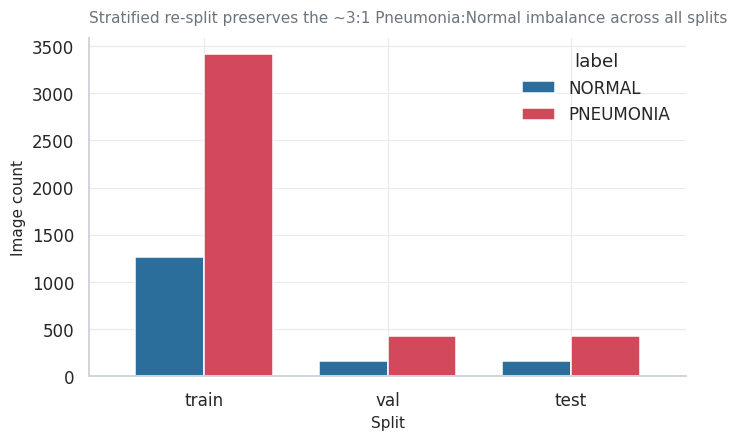

In [3]:
# Class-balance bar chart (saved for the README / model card)
fig, ax = plt.subplots(figsize=(7, 4))
plot_df = df.groupby(['split', 'label']).size().unstack(fill_value=0).reindex(['train', 'val', 'test'])
plot_df = plot_df[[c for c in C.CLASSES if c in plot_df.columns]]
plot_df.plot(kind='bar', ax=ax, color=[vs.CLASS_COLORS[c] for c in plot_df.columns], width=0.75)
ax.set_xlabel('Split'); ax.set_ylabel('Image count')
ax.tick_params(axis='x', rotation=0)
vs.takeaway(ax, 'Stratified re-split preserves the ~3:1 Pneumonia:Normal imbalance across all splits')
fig.savefig(C.ASSETS_DIR / 'eda_class_balance.png')
plt.show()

## Sample images
Sanity-check that labels look right and images are lung fields (not artifacts).

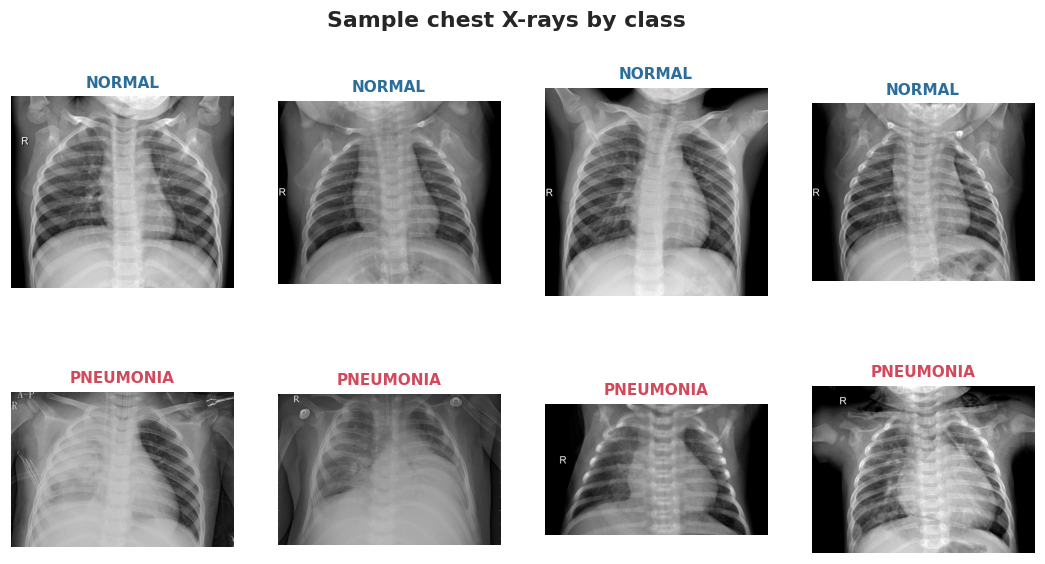

In [4]:
fig, axes = plt.subplots(2, 4, figsize=(12, 6))
for row, cls in enumerate(C.CLASSES):
    sample = df[df['label'] == cls].sample(4, random_state=C.SEED)
    for col, (_, r) in enumerate(sample.iterrows()):
        img = Image.open(r['filepath']).convert('L')
        axes[row, col].imshow(img, cmap='gray')
        axes[row, col].set_title(cls, color=vs.CLASS_COLORS[cls], fontsize=10)
        axes[row, col].axis('off')
fig.suptitle('Sample chest X-rays by class', fontweight='bold')
fig.savefig(C.ASSETS_DIR / 'eda_samples.png')
plt.show()

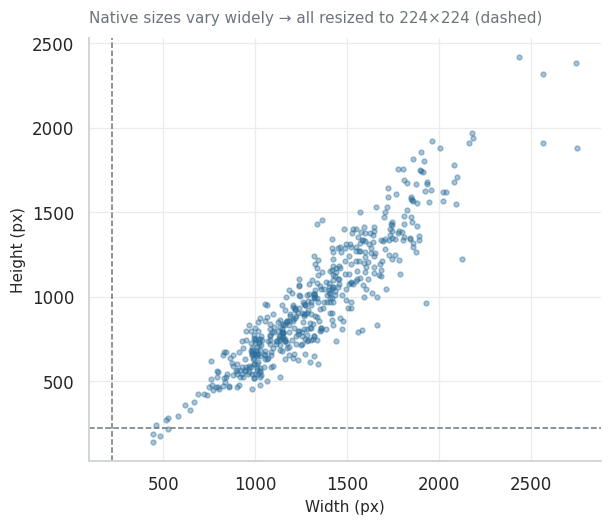

Width  range: 445 - 2752
Height range: 140 - 2418


In [5]:
# Image dimension distribution (on a sample — full set is large)
sample = df.sample(min(500, len(df)), random_state=C.SEED)
dims = np.array([Image.open(p).size for p in sample['filepath']])  # (w, h)
fig, ax = plt.subplots(figsize=(6, 5))
ax.scatter(dims[:, 0], dims[:, 1], s=10, alpha=0.4, color=vs.PRIMARY)
ax.axvline(C.IMG_SIZE, color=vs.MUTED, ls='--', lw=1)
ax.axhline(C.IMG_SIZE, color=vs.MUTED, ls='--', lw=1)
ax.set_xlabel('Width (px)'); ax.set_ylabel('Height (px)')
vs.takeaway(ax, f'Native sizes vary widely → all resized to {C.IMG_SIZE}×{C.IMG_SIZE} (dashed)')
fig.savefig(C.ASSETS_DIR / 'eda_dimensions.png')
plt.show()
print('Width  range:', dims[:, 0].min(), '-', dims[:, 0].max())
print('Height range:', dims[:, 1].min(), '-', dims[:, 1].max())

## Known data issues (the narrative, PRD §5.2)

| Issue | Impact | Mitigation |
|-------|--------|------------|
| Original Kaggle `val/` ≈ 16 images | Meaningless model selection / threshold tuning | **Re-split** stratified 80/10/10 (done, `splits.csv`) |
| Class imbalance ~3:1 | Biased toward Pneumonia | Class weights + augmentation; report PR curve, not just accuracy |
| Kaggle is **pediatric-only** | Won't match adult populations | Drives the external drop vs RSNA (mixed-age) — this *is* the story |
| Different labeling across datasets | Not perfectly comparable to RSNA | State explicitly in the model card |

These points get carried into `MODEL_CARD.md` and the generalization report.